In [1]:
!pip install torch torchvision torchaudio
!pip install git+https://github.com/RobustBench/robustbench.git
!pip install git+https://github.com/fra31/auto-attack
!pip install matplotlib

  Cloning https://github.com/RobustBench/robustbench.git to /tmp/pip-req-build-t1l7r5ji
  Running command git clone --filter=blob:none --quiet https://github.com/RobustBench/robustbench.git /tmp/pip-req-build-t1l7r5ji
  Resolved https://github.com/RobustBench/robustbench.git to commit 78fcc9e48a07a861268f295a777b975f25155964
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/fra31/auto-attack.git (to revision a39220048b3c9f2cca9a4d3a54604793c68eca7e) to /tmp/pip-install-edrlx8vr/autoattack_c5b8516495e54cbda104d233c075e1bd
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack.git /tmp/pip-install-edrlx8vr/autoattack_c5b8516495e54cbda104d233c075e1bd
  Running command git rev-parse -q --verify 'sha^a39220048b3c9f2cca9a4d3a54604793c68eca7e'
  Running command git fetch -q https://github.com/fra31/auto-attack.git a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Resolved https://github.com/fra31/auto-attack.git to commit a39220048b3c9f2cca9a4

In [2]:
#prepares the environment and decides whether computation will run on CPU
import torch
import torch.nn.functional as F
from robustbench import load_model

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


In [3]:
#load two RobustBench models
model_a = load_model(
    model_name="Standard",
    dataset="cifar10",
    threat_model="Linf"
).to(device)

model_b = load_model(
    model_name="Engstrom2019Robustness",
    dataset="cifar10",
    threat_model="Linf"
).to(device)

model_a.eval()
model_b.eval()

print(type(model_a))
print(type(model_b))

Downloading...
From (original): https://drive.google.com/uc?id=1t98aEuzeTL8P7Kpd5DIrCoCL21BNZUhC
From (redirected): https://drive.google.com/uc?id=1t98aEuzeTL8P7Kpd5DIrCoCL21BNZUhC&confirm=t&uuid=11dc29cd-c070-4890-a460-f490b78f9dd0
To: /content/models/cifar10/Linf/Standard.pt
100%|██████████| 292M/292M [00:04<00:00, 71.7MB/s]


Downloading...
From: https://drive.google.com/uc?id=1etqmQsksNIWBvBQ4r8ZFk_3FJlLWr8Rr
To: /content/models/cifar10/Linf/Engstrom2019Robustness.pt
100%|██████████| 94.4M/94.4M [00:02<00:00, 44.5MB/s]


<class 'robustbench.model_zoo.architectures.wide_resnet.WideResNet'>
<class 'robustbench.model_zoo.cifar10.Engstrom2019RobustnessNet'>


In [4]:
#test that both models run correctly
x = torch.randn(1, 3, 32, 32).to(device)

with torch.no_grad():
    y_a = model_a(x)
    y_b = model_b(x)

print("Model A output shape:", y_a.shape)
print("Model B output shape:", y_b.shape)

Model A output shape: torch.Size([1, 10])
Model B output shape: torch.Size([1, 10])


In [5]:
#load real CIFAR-10 test data
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print("Test set loaded:", len(test_dataset))

100%|██████████| 170M/170M [00:05<00:00, 28.8MB/s]


Test set loaded: 10000


In [6]:
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: torch.Size([8, 3, 32, 32])
Labels shape: torch.Size([8])
Labels: tensor([3, 8, 8, 0, 6, 6, 1, 6])


In [7]:
#compare predictions of the two models
with torch.no_grad():
    out_a = model_a(images)
    out_b = model_b(images)

print("Model A output shape:", out_a.shape)
print("Model B output shape:", out_b.shape)


Model A output shape: torch.Size([8, 10])
Model B output shape: torch.Size([8, 10])


In [8]:
#compare predictions of the two models
pred_a = out_a.argmax(dim=1)
pred_b = out_b.argmax(dim=1)

print("True labels: ", labels.cpu().tolist())
print("Pred A:      ", pred_a.cpu().tolist())
print("Pred B:      ", pred_b.cpu().tolist())

True labels:  [3, 8, 8, 0, 6, 6, 1, 6]
Pred A:       [3, 8, 8, 0, 6, 6, 1, 6]
Pred B:       [3, 8, 8, 0, 6, 6, 1, 6]


In [9]:
#Count how many predictions each model got correct in this batch
correct_a = (pred_a == labels).sum().item()
correct_b = (pred_b == labels).sum().item()

print(f"Model A correct: {correct_a}/{labels.size(0)}")
print(f"Model B correct: {correct_b}/{labels.size(0)}")

Model A correct: 8/8
Model B correct: 8/8


In [10]:
#converts numeric class IDs into human-readable CIFAR-10 names
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

for i in range(len(labels)):
    print(f"Image {i}: true={classes[labels[i].item()]}, "
          f"model_a={classes[pred_a[i].item()]}, "
          f"model_b={classes[pred_b[i].item()]}")

Image 0: true=cat, model_a=cat, model_b=cat
Image 1: true=ship, model_a=ship, model_b=ship
Image 2: true=ship, model_a=ship, model_b=ship
Image 3: true=airplane, model_a=airplane, model_b=airplane
Image 4: true=frog, model_a=frog, model_b=frog
Image 5: true=frog, model_a=frog, model_b=frog
Image 6: true=automobile, model_a=automobile, model_b=automobile
Image 7: true=frog, model_a=frog, model_b=frog


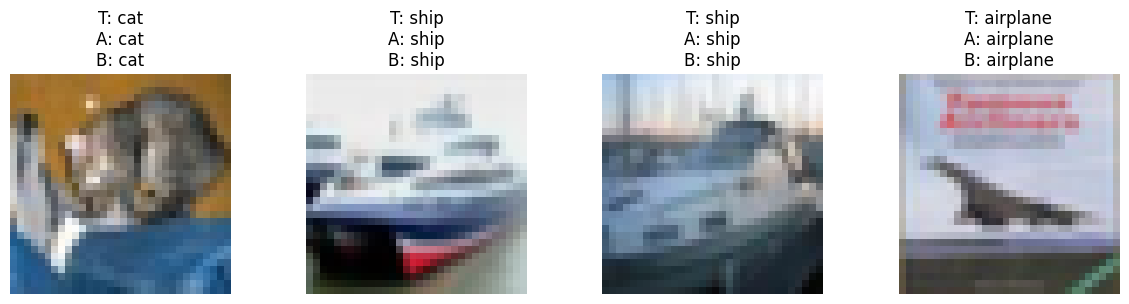

In [11]:
#Show a few images from the batch
import matplotlib.pyplot as plt

num_show = 4
fig, axes = plt.subplots(1, num_show, figsize=(12, 3))

for i in range(num_show):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(
        f"T: {classes[labels[i].item()]}\n"
        f"A: {classes[pred_a[i].item()]}\n"
        f"B: {classes[pred_b[i].item()]}"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [12]:
#Measure clean accuracy on a few batches instead of just one
num_batches = 20
total = 0
correct_a = 0
correct_b = 0

with torch.no_grad():
    for batch_idx, (imgs, lbls) in enumerate(test_loader):
        if batch_idx >= num_batches:
            break

        imgs = imgs.to(device)
        lbls = lbls.to(device)

        out_a = model_a(imgs)
        out_b = model_b(imgs)

        pred_a = out_a.argmax(dim=1)
        pred_b = out_b.argmax(dim=1)

        correct_a += (pred_a == lbls).sum().item()
        correct_b += (pred_b == lbls).sum().item()
        total += lbls.size(0)

print(f"Model A clean accuracy on {total} images: {correct_a/total:.4f}")
print(f"Model B clean accuracy on {total} images: {correct_b/total:.4f}")

Model A clean accuracy on 160 images: 0.9437
Model B clean accuracy on 160 images: 0.9125


In [13]:
#Save one clean batch for later adversarial experiments
clean_images = images.clone().detach()
clean_labels = labels.clone().detach()

print("Saved clean batch:", clean_images.shape, clean_labels.shape)

Saved clean batch: torch.Size([8, 3, 32, 32]) torch.Size([8])


In [14]:
from autoattack import AutoAttack

attacker_a = AutoAttack(
    model_a,
    norm='Linf',
    eps=8/255,
    version='standard',
    device=device
)

print("AutoAttack ready")

setting parameters for standard version
AutoAttack ready


In [15]:
#Run AutoAttack on the clean batch for model_a
adv_images_a = attacker_a.run_standard_evaluation(
    clean_images,
    clean_labels,
    bs=8
)

using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 100.00%
apgd-ce - 1/1 - 8 out of 8 successfully perturbed
robust accuracy after APGD-CE: 0.00% (total time 294.4 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 0.00%


In [16]:
#Evaluate model_a on the adversarial examples
with torch.no_grad():
    adv_out_a = model_a(adv_images_a)

adv_pred_a = adv_out_a.argmax(dim=1)

print("True labels: ", clean_labels.cpu().tolist())
print("Adv pred A:  ", adv_pred_a.cpu().tolist())

acc_a = (adv_pred_a == clean_labels).sum().item()
print(f"Model A accuracy on adversarial examples: {acc_a}/{clean_labels.size(0)}")

True labels:  [3, 8, 8, 0, 6, 6, 1, 6]
Adv pred A:   [6, 1, 2, 8, 1, 3, 3, 3]
Model A accuracy on adversarial examples: 0/8


In [17]:
#Finds all orthogonal adversarial directions for a given input and model
def gaas_directions(model, x, y, epsilon=8/255, max_dirs=50):
    #Evaluation mode
    model.eval()

    #Prepare input by cloning, detaching, adding batch dimension, and moving to device
    x = x.clone().detach().unsqueeze(0).to(device)
    y = y.clone().detach().unsqueeze(0).to(device)

    #Keep track of directions
    directions = []

    #Iteratively find adversarial directions up to max_dirs or until no more can be found
    for i in range(max_dirs):
        #Enable gradient tracking on the input
        x.requires_grad_(True)

        #Forward pass and compute loss
        output = model(x)
        loss = F.cross_entropy(output, y)

        #Clear any accumulated gradients
        model.zero_grad()
        #Backpropagate to get how much each input pixel affects the loss
        loss.backward()

        #Extract the input gradient and flatten to a 1D vector
        g = x.grad.detach().view(-1)

        if len(directions) > 0:
            #For each previously found direction d, subtract its component from g to ensure orthogonality
            for d in directions:
                d_flat = d.view(-1)
                proj = torch.dot(g, d_flat) / (torch.dot(d_flat, d_flat) + 1e-8)
                g = g - proj * d_flat

        #No new direction if the gradient is near zero
        if torch.norm(g) < 1e-10:
            break

        #Reshape 1D gradient back to input shape for perturbation
        g = g.view_as(x)

        #Perturbation in the direction of the sign of the gradient
        delta = epsilon * torch.sign(g)

        #Perturb the input and check if it causes misclassification
        x_adv = x + delta
        pred = model(x_adv).argmax(dim=1)

        #If there misclassification, save this direction
        if pred.item() != y.item():
            directions.append(delta.detach())
        #Otherwise stop searching for more directions since the remaining gradient is not effective
        else:
            break

    return directions

In [18]:
num_samples = 8

#Dimensionality estimate (number of orthogonal adversarial directions) per sample
dims = []

#Find every orthogonal adversarial direction for some images for model_a
for i in range(num_samples):
    x = clean_images[i]
    y = clean_labels[i]

    dirs = gaas_directions(model_a, x, y, max_dirs=50)
    #Keep track of how many directions
    dims.append(len(dirs))

    print(f"Image {i}: subspace dim = {len(dirs)}")

print("Average dimension:", sum(dims)/len(dims))

Image 0: subspace dim = 0
Image 1: subspace dim = 1
Image 2: subspace dim = 14
Image 3: subspace dim = 50
Image 4: subspace dim = 0
Image 5: subspace dim = 1
Image 6: subspace dim = 9
Image 7: subspace dim = 0
Average dimension: 9.375


In [19]:
#Compare the average subspace dimensionality for model_a and model_b
dims_a = []
dims_b = []

for i in range(num_samples):
    x = clean_images[i]
    y = clean_labels[i]

    dims_a.append(len(gaas_directions(model_a, x, y)))
    dims_b.append(len(gaas_directions(model_b, x, y)))

print("Model A avg dim:", sum(dims_a)/len(dims_a))
print("Model B avg dim:", sum(dims_b)/len(dims_b))

Model A avg dim: 9.375
Model B avg dim: 1.875


In [20]:
# The above gaas_directions function uses the L-infinity norm (sign of gradient).
# Here I use the L2 norm instead, as per the paper:
#   r = epsilon * g / ||g||_2
# Everything else stays the same.

def gaas_directions_l2(model, x, y, epsilon=8/255, max_dirs=50):

    model.eval()
    x = x.clone().detach().unsqueeze(0).to(device)
    y = y.clone().detach().unsqueeze(0).to(device)
    directions = []

    for i in range(max_dirs):
        x.requires_grad_(True)
        output = model(x)
        loss = F.cross_entropy(output, y)
        model.zero_grad()
        loss.backward()

        g = x.grad.detach().view(-1)

        # Gram-Schmidt: remove components of already-found directions
        for d in directions:
            d_flat = d.view(-1)
            proj = torch.dot(g, d_flat) / (torch.dot(d_flat, d_flat) + 1e-8)
            g = g - proj * d_flat

        g_norm = torch.norm(g)
        if g_norm < 1e-10:
            break

        g = g.view_as(x)

        # L2 step as the paper describes
        delta = epsilon * g / g_norm

        x_adv = x + delta
        pred = model(x_adv).argmax(dim=1)

        if pred.item() != y.item():
            directions.append(delta.detach())
        else:
            break

    return directions


# (L-inf) vs (L2) norm
print("Comparing L-inf vs L2 GAAS on model_a:")
print(f"{'Image':<8} {'L-inf dirs':>12} {'L2 dirs':>10}")
print("-" * 32)
for i in range(num_samples):
    x_i = clean_images[i]
    y_i = clean_labels[i]
    n_linf = len(gaas_directions(model_a, x_i, y_i, max_dirs=50))
    n_l2   = len(gaas_directions_l2(model_a, x_i, y_i, max_dirs=50))
    print(f"{i:<8} {n_linf:>12} {n_l2:>10}")
print("\nNote: L2 norm may find more or fewer directions depending on geometry.")
print("The L-inf sign step can 'over-shoot' orthogonal directions, which is why counts sometimes differ.")


Comparing L-inf vs L2 GAAS on model_a:
Image      L-inf dirs    L2 dirs
--------------------------------
0                   0          0
1                   1          0
2                  14          2
3                  50          0
4                   0          0
5                   1          0
6                   9          0
7                   0          0

Note: L2 norm may find more or fewer directions depending on geometry.
The L-inf sign step can 'over-shoot' orthogonal directions, which is why counts sometimes differ.



## Subspace Comparison




In [21]:
import numpy as np

# METRIC: Transfer Rate
# For each image, find adversarial directions on model_a, then test
# whether those same directions also fool model_b.

transfer_counts = []   # how many directions from A also fool B
total_dirs_a    = []   # total directions found for A

print("Computing transfer rates (adversarial dirs from model_a tested on model_b):")
print(f"{'Image':<8} {'Dirs(A)':>8} {'To B':>6} {'Rate':>8}")
print("-" * 34)

for i in range(num_samples):
    x_i = clean_images[i]
    y_i = clean_labels[i]

    # find adversarial directions on model_a
    dirs_a = gaas_directions(model_a, x_i, y_i, max_dirs=50)
    total_dirs_a.append(len(dirs_a))

    if len(dirs_a) == 0:
        transfer_counts.append(0)
        print(f"{i:<8} {'no dirs found':>38}")
        continue

    # test each direction from A on model_b
    x_dev = x_i.clone().detach().unsqueeze(0).to(device)
    y_dev = y_i.clone().detach().unsqueeze(0).to(device)

    transferred = 0
    with torch.no_grad():
        for d in dirs_a:
            x_adv = (x_dev + d).clamp(0, 1)    # clip to valid pixel range
            pred_b = model_b(x_adv).argmax(dim=1)
            if pred_b.item() != y_dev.item():   # direction also fools model_b
                transferred += 1

    transfer_counts.append(transferred)
    rate = transferred / len(dirs_a)
    print(f"{i:<8} {len(dirs_a):>8} {transferred:>6} {rate:>7.1%}")

# Summarise (only images where model_a found at least 1 direction)
valid = [(t, d) for t, d in zip(transfer_counts, total_dirs_a) if d > 0]
if valid:
    mean_rate = sum(t / d for t, d in valid) / len(valid)
    print(f"\nMean transfer rate A -> B : {mean_rate:.1%}")
    print(f"Interpretation: on average {mean_rate:.0%} of model A's adversarial")
    print("subspace is shared with model B.")


Computing transfer rates (adversarial dirs from model_a tested on model_b):
Image     Dirs(A)   To B     Rate
----------------------------------
0                                 no dirs found
1               1      0    0.0%
2              14      0    0.0%
3              50      0    0.0%
4                                 no dirs found
5               1      0    0.0%
6               9      0    0.0%
7                                 no dirs found

Mean transfer rate A -> B : 0.0%
Interpretation: on average 0% of model A's adversarial
subspace is shared with model B.


In [22]:

# METRIC: Inter-Boundary Distance
#   INTER-DIST(f1, f2, x) = |MIN-DIST(f1, x) - MIN-DIST(f2, x)|

# We pick an adversarial direction d from model_a, then do a line-search
# to find how far along d each model's boundary is.
# The absolute difference is the inter-boundary distance.
# A small value means both boundaries are roughly at the same place
# along the adversarial direction -> high expected transferability.

def min_dist_along_direction(model, x, y, direction, max_eps=1.0, steps=100):

    model.eval()
    d_flat  = direction.view(-1)
    d_norm  = d_flat.norm()
    d_unit  = (direction / (d_norm + 1e-8)).to(device)

    x_dev = x.clone().detach().unsqueeze(0).to(device)
    y_dev = y.clone().detach().unsqueeze(0).to(device)

    with torch.no_grad():
        for step in range(1, steps + 1):
            alpha = (step / steps) * max_eps
            x_adv = (x_dev + alpha * d_unit).clamp(0, 1)
            pred  = model(x_adv).argmax(dim=1)
            if pred.item() != y_dev.item():
                return alpha   # found the decision boundary crossing

    return max_eps   # boundary not crossed within max_eps -> return max as upper bound


inter_dists = []

print("Computing Inter-Boundary Distances along model_a adversarial directions:")
print(f"{'Image':<8} {'MIN-DIST A':>12} {'MIN-DIST B':>12} {'INTER-DIST':>12}")
print("-" * 48)

for i in range(num_samples):
    x_i = clean_images[i]
    y_i = clean_labels[i]

    # Only need the first adversarial direction for this metric
    dirs_a = gaas_directions(model_a, x_i, y_i, max_dirs=1)

    if len(dirs_a) == 0:
        print(f"{i:<8} {'no direction found':>38}")
        inter_dists.append(None)
        continue

    d = dirs_a[0]
    dist_a = min_dist_along_direction(model_a, x_i, y_i, d)
    dist_b = min_dist_along_direction(model_b, x_i, y_i, d)
    inter  = abs(dist_a - dist_b)
    inter_dists.append(inter)

    print(f"{i:<8} {dist_a:>12.4f} {dist_b:>12.4f} {inter:>12.4f}")

valid_inter = [v for v in inter_dists if v is not None]
if valid_inter:
    print(f"\nMean Inter-Boundary Distance : {np.mean(valid_inter):.4f}")
    print("(Smaller = boundaries are closer = higher expected transferability)")


Computing Inter-Boundary Distances along model_a adversarial directions:
Image      MIN-DIST A   MIN-DIST B   INTER-DIST
------------------------------------------------
0                            no direction found
1              0.1300       1.0000       0.8700
2              0.0100       1.0000       0.9900
3              0.0700       1.0000       0.9300
4                            no direction found
5              0.1400       1.0000       0.8600
6              0.2500       1.0000       0.7500
7                            no direction found

Mean Inter-Boundary Distance : 0.8800
(Smaller = boundaries are closer = higher expected transferability)



## Visualization

We visualise the adversarial subspaces of model_a and model_b in two ways:

1. **PCA scatter plot** - each adversarial direction is a high-dimensional vector.
   We project all directions from both models down to 2D using PCA so we can *see*
   whether the two clouds of points overlap (= shared subspace) or are far apart
   (= different subspaces).

2. **Cosine similarity heatmap** - for every pair of directions (one from A, one from B),
   we compute the cosine similarity. A value of 1 means the same direction, 0 means
   perpendicular (orthogonal), -1 means opposite. High values indicate dimensions that
   both models share in their adversarial subspaces.


Model A: 75 total directions
Model B: 15 total directions


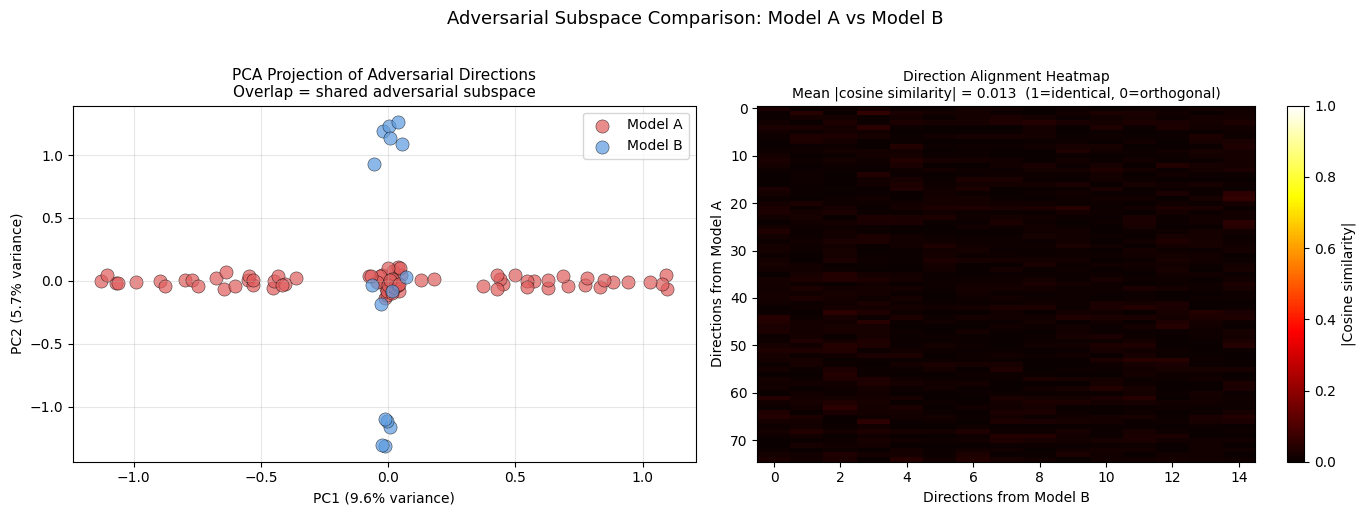


INTERPRETATION GUIDE:

  Mean |cosine similarity| = 0.013
  LOW overlap: adversarial subspaces are mostly orthogonal.
  -> Attacks on model A are unlikely to transfer to model B.
  PCA: top 2 components capture 15.2% of variance
  If A and B points cluster together in the PCA plot,
  their adversarial directions live in the same subspace.


In [24]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Collect all adversarial direction vectors for both models
# We flatten each direction tensor (shape 1x3x32x32) to a 1D vector
# so we can do linear algebra (PCA, cosine similarity) on them.

print("Collecting all adversarial direction vectors:")
all_dirs_a, all_dirs_b = [], []

for i in range(num_samples):
    x_i, y_i = clean_images[i], clean_labels[i]
    for d in gaas_directions(model_a, x_i, y_i, max_dirs=50):
        all_dirs_a.append(d.cpu().view(-1).numpy())
    for d in gaas_directions(model_b, x_i, y_i, max_dirs=50):
        all_dirs_b.append(d.cpu().view(-1).numpy())

print(f"Model A: {len(all_dirs_a)} total directions")
print(f"Model B: {len(all_dirs_b)} total directions")

# Need at least 2 total directions to plot anything meaningful
all_combined = all_dirs_a + all_dirs_b
if len(all_combined) < 2:
    print("Not enough directions found across all images. Cannot visualise.")
else:
    plot_labels = ["Model A"] * len(all_dirs_a) + ["Model B"] * len(all_dirs_b)
    X = np.array(all_combined)   # shape: (total_directions, flattened_image_size)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # PCA 2D scatter
    # PCA finds the two directions of maximum spread in our high-D data.
    # If points from A and B cluster together -> shared subspace.
    # If they form separate clusters -> different subspaces.

    n_components = min(2, X.shape[0], X.shape[1])
    pca  = PCA(n_components=n_components)
    X_2d = pca.fit_transform(X)

    ax = axes[0]
    colors = {"Model A": "#E05C5C", "Model B": "#5C9BE0"}
    for lbl, col in colors.items():
        mask = np.array([l == lbl for l in plot_labels])
        pts  = X_2d[mask]
        if len(pts) > 0:
            y_vals = pts[:, 1] if n_components == 2 else np.zeros(len(pts))
            ax.scatter(pts[:, 0], y_vals, c=col, label=lbl,
                       alpha=0.7, edgecolors="k", linewidths=0.4, s=90)

    var_x = pca.explained_variance_ratio_[0]
    var_y = pca.explained_variance_ratio_[1] if n_components == 2 else 0
    ax.set_xlabel(f"PC1 ({var_x:.1%} variance)")
    ax.set_ylabel(f"PC2 ({var_y:.1%} variance)")
    ax.set_title("PCA Projection of Adversarial Directions\n"
                 "Overlap = shared adversarial subspace", fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Cosine similarity heatmap
    # Each cell (i, j) = how aligned direction i from A is with direction j from B.
    # Bright (high value) = similar direction = shared adversarial dimension.
    # Mostly dark = the two subspaces are mostly orthogonal.

    ax2 = axes[1]
    if len(all_dirs_a) > 0 and len(all_dirs_b) > 0:
        A = np.array(all_dirs_a)   # (nA, D)
        B = np.array(all_dirs_b)   # (nB, D)

        # Normalise each row to unit length before dot product = cosine similarity
        A_norm = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-8)
        B_norm = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-8)
        cos_sim = A_norm @ B_norm.T   # (nA, nB)

        # Use absolute value: we care about direction alignment, not sign
        im = ax2.imshow(np.abs(cos_sim), aspect="auto", cmap="hot", vmin=0, vmax=1)
        plt.colorbar(im, ax=ax2, label="|Cosine similarity|")

        mean_cos = float(np.mean(np.abs(cos_sim)))
        ax2.set_xlabel("Directions from Model B")
        ax2.set_ylabel("Directions from Model A")
        ax2.set_title(f"Direction Alignment Heatmap\n"
                      f"Mean |cosine similarity| = {mean_cos:.3f}  "
                      f"(1=identical, 0=orthogonal)", fontsize=10)
    else:
        ax2.text(0.5, 0.5, "Too few directions to compare",
                 ha="center", va="center", transform=ax2.transAxes)
        mean_cos = None

    plt.suptitle("Adversarial Subspace Comparison: Model A vs Model B",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # Summary interpretation
    print("\nINTERPRETATION GUIDE:\n")

    if mean_cos is not None:
        print(f"  Mean |cosine similarity| = {mean_cos:.3f}")
        if mean_cos > 0.5:
            print("  HIGH overlap: models share a large adversarial subspace.")
            print("  -> Expect high cross-model attack transferability.")
        elif mean_cos > 0.2:
            print("  MODERATE overlap: partial subspace sharing.")
            print("  -> Some attacks will transfer, but not all.")
        else:
            print("  LOW overlap: adversarial subspaces are mostly orthogonal.")
            print("  -> Attacks on model A are unlikely to transfer to model B.")
    print(f"  PCA: top 2 components capture "
          f"{sum(pca.explained_variance_ratio_):.1%} of variance")
    print("  If A and B points cluster together in the PCA plot,")
    print("  their adversarial directions live in the same subspace.")
